In [1]:
# data imports -> ! run once per runtime
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# tf.keras.utils.get_file with extract=True is expected to return the path to the extracted directory.
# We will directly assign this return value to data_dir.
data_dir = tf.keras.utils.get_file(origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir)

# The flower_photos dataset typically extracts into a top-level directory
# which itself contains another directory named 'flower_photos' that holds the category subdirectories.
# We adjust data_dir to point to this nested directory if it exists.
if (data_dir / 'flower_photos').is_dir():
    data_dir = data_dir / 'flower_photos'

# After this, data_dir should point to the directory containing 'daisy', 'dandelion', etc.

2025-12-10 09:39:51.237353: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765359591.443621      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765359591.501079      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 13.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

In [3]:
# other necessary imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from tqdm import tqdm
from torchmetrics import Accuracy, F1Score

In [4]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)
print(os.listdir(data_dir))

3670
['roses', 'dandelion', 'sunflowers', 'LICENSE.txt', 'daisy', 'tulips']


641


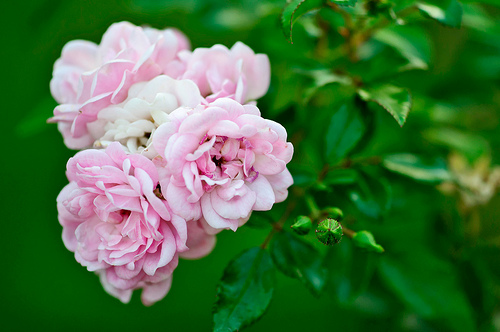

In [5]:
roses = list(data_dir.glob('roses/*'))
print(len(roses))
img = PIL.Image.open(str(roses[2]))
image = PIL.Image.open(str(roses[3]))
image = np.array(image)
image.shape
img
# => initial image shape:

In [6]:

import torchvision.transforms as transforms
from torch.utils.data import DataLoader


# Create the dataset using ImageFolder
# data_dir should be the path to your 'flower_photos' directory containing 'roses', 'daisy', etc.
full_dataset = torchvision.datasets.ImageFolder(
    root=data_dir
)

print(f"Number of images in the dataset: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")


Number of images in the dataset: 3670
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [7]:
from sklearn.model_selection import train_test_split

targets = full_dataset.targets

train_indices, test_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.1,
    stratify=targets,
    random_state=42
)


In [8]:

# WITH Augmentation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.RandomResizedCrop(128, scale=(0.6, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# NO Augmentation
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [9]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label


In [10]:
train_dataset = TransformSubset(full_dataset, train_indices, train_transform)
test_dataset  = TransformSubset(full_dataset, test_indices, test_transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)


Class distribution in Training Dataset:
sunflowers: 629 samples
roses: 577 samples
tulips: 719 samples
dandelion: 808 samples
daisy: 570 samples


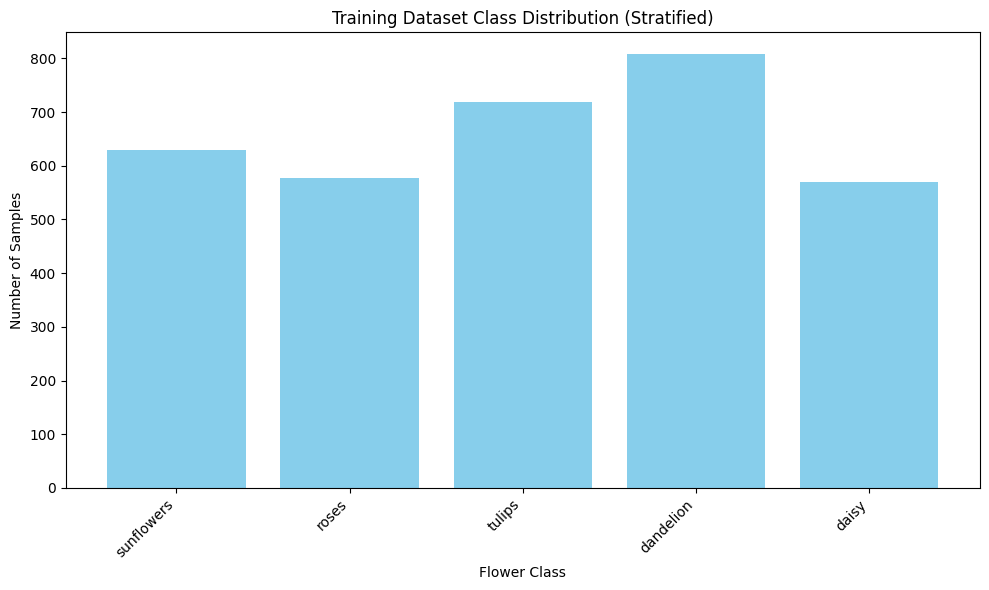

In [11]:
import collections
import matplotlib.pyplot as plt

# Get the class labels for the training dataset
train_labels = [full_dataset.targets[i] for i in train_dataset.indices]

# Count the occurrences of each class
class_counts = collections.Counter(train_labels)

# Get the class names from the original full_dataset
class_names = full_dataset.classes

# Prepare data for plotting
labels = [class_names[label] for label in class_counts.keys()]
counts = list(class_counts.values())

print("Class distribution in Training Dataset:")
for label, count in zip(labels, counts):
    print(f"{label}: {count} samples")

# Plotting the distribution
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Flower Class')
plt.ylabel('Number of Samples')
plt.title('Training Dataset Class Distribution (Stratified)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 320 -> 160

            nn.Conv2d(32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 160 -> 80

            nn.Conv2d(64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 80 -> 40

            nn.Conv2d(128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), 

            nn.Conv2d(128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 40 -> 20
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
# if cuda is available use gpu else cpu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Net(in_channels=3, num_classes=5).to(device)

In [13]:
print(model)

Net(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

criterion.to(device)

CrossEntropyLoss()

In [15]:
num_epochs = 200


train_acc = Accuracy(task="multiclass", num_classes=5).to(device)
train_f1 = F1Score(task="multiclass", num_classes=5, average="macro").to(device)

print(f"Device: {device}")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    num_batches = 0

    # reset metrics for this epoch
    train_acc.reset()
    train_f1.reset()

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    for data, targets in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False):
        data, targets = data.to(device), targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update metrics
        preds = outputs.argmax(dim=1)
        train_acc.update(preds, targets)
        train_f1.update(preds, targets)

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    epoch_acc = train_acc.compute().item()
    epoch_f1 = train_f1.compute().item()

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | "
          f"Train F1: {epoch_f1:.4f}")


Device: cuda

Epoch 1/200


Epoch [1/200] - Loss: 1.6136 | Train Acc: 0.2519 | Train F1: 0.2194

Epoch 2/200


Epoch [2/200] - Loss: 1.4992 | Train Acc: 0.3321 | Train F1: 0.3061

Epoch 3/200


Epoch [3/200] - Loss: 1.4046 | Train Acc: 0.3939 | Train F1: 0.3664

Epoch 4/200


Epoch [4/200] - Loss: 1.3783 | Train Acc: 0.3875 | Train F1: 0.3625

Epoch 5/200


...

Epoch [196/200] - Loss: 0.2958 | Train Acc: 0.9010 | Train F1: 0.8994

Epoch 197/200


Epoch [197/200] - Loss: 0.2623 | Train Acc: 0.9086 | Train F1: 0.9076

Epoch 198/200


Epoch [198/200] - Loss: 0.2489 | Train Acc: 0.9134 | Train F1: 0.9124

Epoch 199/200


Epoch [199/200] - Loss: 0.2330 | Train Acc: 0.9270 | Train F1: 0.9255

Epoch 200/200


Epoch [200/200] - Loss: 0.2546 | Train Acc: 0.9155 | Train F1: 0.9144


In [16]:
print("\nFinal Evaluation:")
model.eval()

acc_metric = Accuracy(task="multiclass", num_classes=5).to(device)
f1_metric = F1Score(task="multiclass", num_classes=5, average='macro').to(device)


with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final Evaluation"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        acc_metric.update(preds, labels)
        f1_metric.update(preds, labels)

final_accuracy = acc_metric.compute()
final_macro_f1 = f1_metric.compute()

print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test Macro F1 Score: {final_macro_f1:.4f}")



Final Evaluation:


Final Evaluation: 100%|██████████| 12/12 [00:00<00:00, 15.74it/s]

Final Test Accuracy: 0.9019
Final Test Macro F1 Score: 0.9009


In [ ]:
# num_epochs = 200

# train_acc = Accuracy(task="multiclass", num_classes=5).to(device)
# train_f1 = F1Score(task="multiclass", num_classes=5, average="macro").to(device)

# print(f"Device: {device}")

# # Reset histories before training
# train_losses = []
# val_losses = []
# train_accuracies = []
# val_accuracies = []

# for epoch in range(num_epochs):
#     model.train()
#     epoch_loss = 0
#     num_batches = 0

#     train_acc.reset()
#     train_f1.reset()

#     print(f"\nEpoch {epoch+1}/{num_epochs}")

#     # -----------------------------
#     # TRAINING LOOP
#     # -----------------------------
#     for data, targets in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False):
#         data, targets = data.to(device), targets.to(device)

#         outputs = model(data)
#         loss = criterion(outputs, targets)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         preds = outputs.argmax(dim=1)
#         train_acc.update(preds, targets)
#         train_f1.update(preds, targets)

#         epoch_loss += loss.item()
#         num_batches += 1

#     avg_loss = epoch_loss / num_batches
#     epoch_acc = train_acc.compute().item()

#     train_losses.append(avg_loss)
#     train_accuracies.append(epoch_acc)

#     print(f"Epoch [{epoch+1}/{num_epochs}] - "
#           f"Loss: {avg_loss:.4f} | Train Acc: {epoch_acc:.4f}")

#     # ------------------------------------------------------
#     # >>> VALIDATION (ONCE PER EPOCH — SAME COUNT AS TRAIN)
#     # ------------------------------------------------------
#     model.eval()
#     val_loss = 0.0
#     val_batches = 0
#     val_acc_metric = Accuracy(task="multiclass", num_classes=5).to(device)

#     with torch.no_grad():
#         for images, labels in test_loader:
#             images, labels = images.to(device), labels.to(device)

#             outputs = model(images)
#             loss = criterion(outputs, labels)

#             _, preds = torch.max(outputs, 1)
#             val_acc_metric.update(preds, labels)

#             val_loss += loss.item()
#             val_batches += 1

#     avg_val_loss = val_loss / val_batches
#     avg_val_acc = val_acc_metric.compute().item()

#     val_losses.append(avg_val_loss)        # SAME length as train_losses
#     val_accuracies.append(avg_val_acc)     # SAME length as train_accuracies

#     print(f"Validation - Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f}")


In [ ]:
# import matplotlib.pyplot as plt

# epochs = range(1, len(train_losses) + 1)

# plt.figure(figsize=(8,5))
# plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
# plt.plot(epochs, val_losses, label="Validation Loss", linewidth=2)
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
# plt.figure(figsize=(8,5))
# plt.plot(epochs, train_accuracies, label="Train Accuracy", linewidth=2)
# plt.plot(epochs, val_accuracies, label="Validation Accuracy", linewidth=2)
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Training vs Validation Accuracy")
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import numpy as np

# # Collect predictions & true labels
# all_preds = []
# all_labels = []

# model.eval()
# with torch.no_grad():
#     for images, labels in test_loader:
#         images = images.to(device)
#         outputs = model(images)
#         _, preds = torch.max(outputs, 1)

#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# # Build confusion matrix
# cm = confusion_matrix(all_labels, all_preds)


In [ ]:
# plt.figure(figsize=(8,6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted Class")
# plt.ylabel("True Class")
# plt.show()


In [17]:
torch.save(model.state_dict(), "best_model1.pth")

# to load this model later
# model = Net(in_channels=3, num_classes=5)
# model.load_state_dict(torch.load("best_model.pth"))
# model.eval()

In [18]:
import json

results = {
    "test_accuracy": float(final_accuracy),
    "test_macro_f1": float(final_macro_f1),
    "train_accuracy": float(epoch_acc),
    "train_macro_f1": float(epoch_f1),
    "model_architecture": "Custom CNN 32-64-128-256 Conv Blocks",
    "input_size": "128x128",
    "date": "2025-02-08"
}

with open("results1.json", "w") as f:
    json.dump(results, f, indent=4)
